# Step 3: Feature Selection, Data Quality Checks & Descriptive Statistics
### DI 501 Term Project — Eda Yilmaz

**Research Questions:**
- **RQ1:** Does maize yield instability (CV of detrended yield) differ significantly across three European climate panels (Mediterranean / Temperate / Continental)? → Kruskal-Wallis test
- **RQ2:** Can engineered climate stress indicators predict detrended maize yield at subnational level?

**Countries & Panel Assignment:**

| Panel | Countries | Codes |
|---|---|---|
| Mediterranean | Italy, Spain, Greece | IT, ES, EL |
| Temperate | Germany, France, Austria | DE, FR, AT |
| Continental | Romania, Hungary, Poland | RO, HU, PL |

---

## 0. Libraries & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats


sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120
PANEL_COLORS = {
    'Mediterranean': '#e07b39',
    'Temperate':     '#3b82c4',
    'Continental':   '#5aad5a'
}


PANEL_MAP = {
    'IT': 'Mediterranean', 'ES': 'Mediterranean', 'EL': 'Mediterranean',
    'DE': 'Temperate',     'FR': 'Temperate',     'AT': 'Temperate',
    'RO': 'Continental',   'HU': 'Continental',   'PL': 'Continental'
}
COUNTRIES = list(PANEL_MAP.keys())

COUNTRY_NAMES = {
    'IT': 'Italy', 'ES': 'Spain',   'EL': 'Greece',
    'DE': 'Germany','FR': 'France', 'AT': 'Austria',
    'RO': 'Romania','HU': 'Hungary','PL': 'Poland'
}

DATA_PATH = './cybench-data/maize'


GS_MONTHS   = list(range(4, 10))   # April–September (growing season)
JJA_MONTHS  = [6, 7, 8]            # June–July–August (grain-filling)
HEAT_THRESH = 30.0                  # °C — heat stress threshold for maize

print('Countries:', COUNTRIES)

Countries: ['IT', 'ES', 'EL', 'DE', 'FR', 'AT', 'RO', 'HU', 'PL']


---
## 1. Feature Definitions

All features are derived from the CY-Bench dataset (Bognár et al., 2024). The table below lists every variable used in the analysis, its source file, and the literature that motivates its inclusion.

### 1.1 Target Variable

| Variable | Description | Source | Unit |
|---|---|---|---|
| `yield` | Annual grain maize yield at NUTS-2/3 level | `yield_maize_{CN}.csv` | t/ha |

### 1.2 Engineered Variables (for RQ1)

| Variable | Description | Method |
|---|---|---|
| `detrended_yield` | Technology-trend-removed yield | OLS linear regression of yield on year per adm_id; residuals saved (Lobell & Field, 2007) |
| `cv` | Coefficient of Variation of detrended yield | SD / mean per adm_id, expressed as % |
| `panel` | Climate panel label | Assigned by country code |

### 1.3 Climate Stress Features (for RQ2)

| Feature | Description | Source column | Window | Literature |
|---|---|---|---|---|
| `heat_stress_days` | Days where tmax > 30°C | `tmax` (meteo) | June–August | Zampieri et al. (2019), Harsányi et al. (2023) |
| `cwb_deficit_gs` | Cumulative negative crop water balance | `cwb = prec − ET₀` (meteo) | April–September | Lecerf & Ceglar (2019), Zampieri et al. (2019) |
| `tavg_jja` | Mean temperature, grain-filling period | `tavg` (meteo) | June–August | Harsányi et al. (2023), Reidsma et al. (2009) |
| `prec_gs` | Total precipitation, growing season | `prec` (meteo) | April–September | Lischeid et al. (2022) |
| `rsm_anomaly` | Root-zone soil moisture anomaly (standardised) | `rsm` (soil_moisture) | July–August | Zampieri et al. (2019) |

> **Note on `rsm_anomaly`:** Root-zone soil moisture data in CY-Bench is available from 2003 onwards only. This feature will be used as a supplementary variable; the primary ML model will be trained on the full time series using the first four features.

---
## 2. Data Loading & Temporal Coverage Check

In [2]:
def load_yield(cn):
    path = os.path.join(DATA_PATH, cn, f'yield_maize_{cn}.csv')
    df = pd.read_csv(path)
    df = df[['adm_id', 'harvest_year', 'yield']].dropna(subset=['yield'])
    df['country'] = cn
    df['panel']   = PANEL_MAP[cn]
    return df

def load_meteo(cn):
    path = os.path.join(DATA_PATH, cn, f'meteo_maize_{cn}.csv')
    df = pd.read_csv(path, parse_dates=['date'])
    df['month'] = df['date'].dt.month
    df['year']  = df['date'].dt.year
    return df

def load_soil_moisture(cn):
    path = os.path.join(DATA_PATH, cn, f'soil_moisture_maize_{cn}.csv')
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, parse_dates=['date'])
    df['month'] = df['date'].dt.month
    df['year']  = df['date'].dt.year
    return df

yield_frames = []
coverage_rows = []

for cn in COUNTRIES:
    ydf = load_yield(cn)
    years = sorted(ydf['harvest_year'].unique())
    sm_df = load_soil_moisture(cn)
    sm_years = sorted(sm_df['year'].unique()) if sm_df is not None else []
    
    coverage_rows.append({
        'Country':       COUNTRY_NAMES[cn],
        'Code':          cn,
        'Panel':         PANEL_MAP[cn],
        'Regions (n)':   ydf['adm_id'].nunique(),
        'Yield start':   years[0],
        'Yield end':     years[-1],
        'Yield records': len(ydf),
        'SM start':      sm_years[0] if sm_years else 'N/A',
        'SM end':        sm_years[-1] if sm_years else 'N/A',
    })
    yield_frames.append(ydf)

yield_all = pd.concat(yield_frames, ignore_index=True)
coverage_df = pd.DataFrame(coverage_rows)

print('TEMPORAL COVERAGE BY COUNTRY')
print(coverage_df.to_string(index=False))
print(f'\nTotal yield records: {len(yield_all):,}')
print(f'Total regions:       {yield_all["adm_id"].nunique()}')

TEMPORAL COVERAGE BY COUNTRY
Country Code         Panel  Regions (n)  Yield start  Yield end  Yield records  SM start  SM end
  Italy   IT Mediterranean          103         1995       2020           2325      2003    2023
  Spain   ES Mediterranean           53         1998       2020           1146      2003    2023
 Greece   EL Mediterranean           52         2009       2019            559      2003    2023
Germany   DE     Temperate          372         1979       2021           9095      2003    2023
 France   FR     Temperate           95         1989       2020           3026      2003    2023
Austria   AT     Temperate            9         1975       2020            414      2003    2023
Romania   RO   Continental           42         1998       2020            946      2003    2023
Hungary   HU   Continental           20         1996       2020            459      2003    2023
 Poland   PL   Continental           17         2003       2020            301      2003    2023



---
## 3. Feature Engineering

In [3]:
def engineer_climate_features(cn):
    """
    For a single country, aggregate daily meteorological data
    into annual climate stress indicators per adm_id.
    """
    meteo = load_meteo(cn)

    jja = meteo[meteo['month'].isin(JJA_MONTHS)].copy()
    hsd = (
        jja.assign(hot=(jja['tmax'] > HEAT_THRESH).astype(int))
           .groupby(['adm_id', 'year'])['hot']
           .sum()
           .reset_index()
           .rename(columns={'hot': 'heat_stress_days', 'year': 'harvest_year'})
    )

    gs = meteo[meteo['month'].isin(GS_MONTHS)].copy()
    gs['cwb_neg'] = gs['cwb'].clip(upper=0)  
    cwb_def = (
        gs.groupby(['adm_id', 'year'])['cwb_neg']
          .sum()
          .reset_index()
          .rename(columns={'cwb_neg': 'cwb_deficit_gs', 'year': 'harvest_year'})
    )

    cwb_def['cwb_deficit_gs'] = cwb_def['cwb_deficit_gs'].abs()


    tavg_jja = (
        jja.groupby(['adm_id', 'year'])['tavg']
           .mean()
           .reset_index()
           .rename(columns={'tavg': 'tavg_jja', 'year': 'harvest_year'})
    )

    prec_gs = (
        gs.groupby(['adm_id', 'year'])['prec']
          .sum()
          .reset_index()
          .rename(columns={'prec': 'prec_gs', 'year': 'harvest_year'})
    )


    feats = hsd.merge(cwb_def, on=['adm_id', 'harvest_year'], how='outer')
    feats = feats.merge(tavg_jja,  on=['adm_id', 'harvest_year'], how='outer')
    feats = feats.merge(prec_gs,   on=['adm_id', 'harvest_year'], how='outer')
    feats['country'] = cn
    return feats


print('Engineering climate features for all countries...')
climate_frames = []
for cn in COUNTRIES:
    print(f'  Processing {cn}...', end=' ')
    cf = engineer_climate_features(cn)
    climate_frames.append(cf)
    print(f'({len(cf):,} rows)')

climate_all = pd.concat(climate_frames, ignore_index=True)
print(f'\nTotal climate feature rows: {len(climate_all):,}')

Engineering climate features for all countries...
  Processing IT... (2,484 rows)
  Processing ES... (1,196 rows)
  Processing EL... (989 rows)
  Processing DE... (9,200 rows)
  Processing FR... (2,231 rows)
  Processing AT... (207 rows)
  Processing RO... (966 rows)
  Processing HU... (460 rows)
  Processing PL... (391 rows)

Total climate feature rows: 18,124


In [4]:
# Root-zone soil moisture anomaly (2003+, supplementary):
print('Computing root-zone soil moisture anomaly (RSM, JJA, 2003+)...')
sm_frames = []
for cn in COUNTRIES:
    sm = load_soil_moisture(cn)
    if sm is None:
        print(f'  {cn}: no soil moisture file, skipping')
        continue
    jja_sm = sm[sm['month'].isin(JJA_MONTHS)].copy()
    # Annual mean RSM per adm_id:
    ann = jja_sm.groupby(['adm_id', 'year'])['rsm'].mean().reset_index()
    # Historical mean and std per adm_id:
    ref = ann.groupby('adm_id')['rsm'].agg(['mean', 'std']).reset_index()
    ref.columns = ['adm_id', 'rsm_mean', 'rsm_std']
    ann = ann.merge(ref, on='adm_id')
    ann['rsm_anomaly'] = (ann['rsm'] - ann['rsm_mean']) / ann['rsm_std']
    ann = ann.rename(columns={'year': 'harvest_year'})[['adm_id', 'harvest_year', 'rsm_anomaly']]
    ann['country'] = cn
    sm_frames.append(ann)
    print(f'{cn}: {len(ann):,} rows (years {sm["year"].min()}–{sm["year"].max()})')

rsm_all = pd.concat(sm_frames, ignore_index=True)
print(f'\nRSM anomaly rows total: {len(rsm_all):,}')

Computing root-zone soil moisture anomaly (RSM, JJA, 2003+)...
IT: 2,268 rows (years 2003–2023)
ES: 1,092 rows (years 2003–2023)
EL: 840 rows (years 2003–2023)
DE: 8,379 rows (years 2003–2023)
FR: 2,016 rows (years 2003–2023)
AT: 189 rows (years 2003–2023)
RO: 882 rows (years 2003–2023)
HU: 420 rows (years 2003–2023)
PL: 357 rows (years 2003–2023)

RSM anomaly rows total: 16,443


In [5]:
# Linear detrending per adm_id (for RQ1):
def detrend_yield(df):
    """
    For each adm_id, fit OLS: yield ~ year,
    return the residuals as detrended_yield.
    Requires at least 5 observations.
    (Lobell & Field, 2007 approach)
    """
    out_rows = []
    for adm_id, grp in df.groupby('adm_id'):
        grp = grp.sort_values('harvest_year')
        if len(grp) < 5:
            continue
        x = grp['harvest_year'].values
        y = grp['yield'].values
        slope, intercept, _, _, _ = stats.linregress(x, y)
        trend = intercept + slope * x
        residuals = y - trend
        grp = grp.copy()
        grp['detrended_yield'] = residuals
        grp['trend_slope']     = slope
        out_rows.append(grp)
    return pd.concat(out_rows, ignore_index=True)

print('Applying linear detrending per adm_id...')
yield_detrended = detrend_yield(yield_all)

# Computeatiton of CV per adm_id:
cv_df = (
    yield_detrended
    .groupby(['adm_id', 'country', 'panel'])
    .apply(lambda grp: pd.Series({
        'cv': np.std(grp['detrended_yield']) / np.abs(np.mean(grp['yield'])) * 100
        if np.mean(grp['yield']) != 0 else np.nan
    }), include_groups=False)
    .reset_index()
)

print(f'Detrended rows: {len(yield_detrended):,} | CV computed for {len(cv_df):,} regions')
print('\nCV by panel (preview):')
print(cv_df.groupby('panel')['cv'].describe().round(3))

Applying linear detrending per adm_id...
Detrended rows: 18,149 | CV computed for 717 regions

CV by panel (preview):
               count    mean     std    min     25%     50%     75%      max
panel                                                                       
Continental     79.0  24.980  11.390  8.226  18.947  23.004  30.188   81.016
Mediterranean  201.0  16.798  13.394  1.197   8.211  14.613  19.767  100.901
Temperate      430.0  13.178   8.246  2.735   9.498  11.577  14.410   89.311


In [6]:

master = (
    yield_detrended
    .merge(climate_all, on=['adm_id', 'harvest_year', 'country'], how='left')
    .merge(rsm_all,     on=['adm_id', 'harvest_year', 'country'], how='left')
)

print(f'Master dataset shape: {master.shape}')
print('\nColumns:')
print(master.columns.tolist())
print('\nFirst 3 rows:')
master.head(3)

Master dataset shape: (18149, 12)

Columns:
['adm_id', 'harvest_year', 'yield', 'country', 'panel', 'detrended_yield', 'trend_slope', 'heat_stress_days', 'cwb_deficit_gs', 'tavg_jja', 'prec_gs', 'rsm_anomaly']

First 3 rows:


,adm_id,harvest_year,yield,country,panel,detrended_yield,trend_slope,heat_stress_days,cwb_deficit_gs,tavg_jja,prec_gs,rsm_anomaly
0,AT11,1975,5.470,AT,Temperate,-1.098763,0.058717,NaN,NaN,NaN,NaN,NaN
1,AT11,1976,4.556,AT,Temperate,-2.071480,0.058717,NaN,NaN,NaN,NaN,NaN
2,AT11,1977,6.689,AT,Temperate,0.002803,0.058717,NaN,NaN,NaN,NaN,NaN


---
## 4. Data Quality Checks
### 4.1 Duplicate Records

In [7]:
FEATURE_COLS = ['yield', 'detrended_yield', 'heat_stress_days',
                'cwb_deficit_gs', 'tavg_jja', 'prec_gs', 'rsm_anomaly']

n_dup = master.duplicated(subset=['adm_id', 'harvest_year']).sum()
print(f'Duplicate (adm_id, harvest_year) records: {n_dup}')
print('-> No duplicates expected (each region × year should be unique)')

Duplicate (adm_id, harvest_year) records: 0
-> No duplicates expected (each region × year should be unique)


### 4.2 Missing Values — Feature-Level

In [8]:
missing_rows = []
for cn in COUNTRIES:
    sub = master[master['country'] == cn]
    row = {'Country': COUNTRY_NAMES[cn], 'Panel': PANEL_MAP[cn], 'N': len(sub)}
    for col in FEATURE_COLS:
        n_miss = sub[col].isna().sum()
        pct    = 100 * n_miss / len(sub)
        row[col] = f'{n_miss} ({pct:.0f}%)'
    missing_rows.append(row)

total_row = {'Country': 'ALL', 'Panel': '—', 'N': len(master)}
for col in FEATURE_COLS:
    n_miss = master[col].isna().sum()
    pct    = 100 * n_miss / len(master)
    total_row[col] = f'{n_miss} ({pct:.0f}%)'
missing_rows.append(total_row)

miss_df = pd.DataFrame(missing_rows)
print('MISSING VALUES PER FEATURE PER COUNTRY')
print(miss_df.to_string(index=False))
print()
print('IMPORTANT: CY-Bench meteo data starts in 2001.')
print('Years before 2001 have yield data but no climate features.')
print('These structural NaNs are not imputed — they are planning to be excluded from RQ2.')
print()
print('ANALYSIS SUBSETS:')
print('RQ1 uses full yield time series (all years) for detrending + CV.')
print('RQ2 uses 2001-2021 only (meteo available). See master_ml dataset.')
print('rsm_anomaly supplementary model: 2003-2021 only.')


MISSING VALUES PER FEATURE PER COUNTRY
Country         Panel     N  yield detrended_yield heat_stress_days cwb_deficit_gs   tavg_jja    prec_gs rsm_anomaly
  Italy Mediterranean  2323 0 (0%)          0 (0%)        434 (19%)      434 (19%)  434 (19%)  434 (19%)   634 (27%)
  Spain Mediterranean  1146 0 (0%)          0 (0%)        195 (17%)      195 (17%)  195 (17%)  195 (17%)   281 (25%)
 Greece Mediterranean   559 0 (0%)          0 (0%)         87 (16%)       87 (16%)   87 (16%)   87 (16%)   119 (21%)
Germany     Temperate  8975 0 (0%)          0 (0%)       5115 (57%)     5115 (57%) 5115 (57%) 5115 (57%)  5623 (63%)
 France     Temperate  3026 0 (0%)          0 (0%)       1148 (38%)     1148 (38%) 1148 (38%) 1148 (38%)  1336 (44%)
Austria     Temperate   414 0 (0%)          0 (0%)        234 (57%)      234 (57%)  234 (57%)  234 (57%)   252 (61%)
Romania   Continental   946 0 (0%)          0 (0%)        122 (13%)      122 (13%)  122 (13%)  122 (13%)   206 (22%)
Hungary   Continental   4

### 4.3 Outlier Detection — IQR Method

In [22]:
def iqr_outliers(series, factor=3.0):
    """
    Returns a boolean mask: True where value is an extreme outlier
    (beyond Q1 - factor*IQR or Q3 + factor*IQR).
    Factor=3.0 flags only extreme points, not natural variability.
    """
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

print('EXTREME OUTLIER DETECTION (IQR × 3.0)')
print(f'{"Feature":<22} {"N valid":>8} {"N outliers":>12} {"% outliers":>12} {"Examples (adm_id, year)"}')
print('-' * 90)

outlier_report = []
for col in FEATURE_COLS:
    valid = master[col].dropna()
    mask  = iqr_outliers(valid)
    n_out = mask.sum()
    pct   = 100 * n_out / len(valid)
  
    idx = valid[mask].index[:3]
    examples = master.loc[idx, ['adm_id', 'harvest_year', col]].values.tolist() if n_out > 0 else []
    ex_str = str([(e[0], e[1]) for e in examples]) if examples else '—'
    
    print(f'{col:<22} {len(valid):>8,} {n_out:>12} {pct:>11.2f}%  {ex_str}')
    outlier_report.append({'feature': col, 'n_valid': len(valid), 'n_outliers': n_out, 'pct': round(pct, 2)})

print()
print('Decision: Extreme outliers in yield (>3 IQR) will be investigated.')
print('If attributable to reporting errors (e.g., yield=0 for missing harvest),')
print('they will be removed before modelling. Natural drought/heat events are retained.')

EXTREME OUTLIER DETECTION (IQR × 3.0)
Feature                 N valid   N outliers   % outliers Examples (adm_id, year)
------------------------------------------------------------------------------------------
yield                    18,149            9        0.05%  [('EL306', 2017), ('EL306', 2018), ('EL431', 2009)]
detrended_yield          18,149          128        0.71%  [('AT21', 2013), ('DE116', 2020), ('DE268', 2018)]
heat_stress_days         10,746           29        0.27%  [('EL521', 2012), ('EL611', 2012), ('ES613', 2001)]
cwb_deficit_gs           10,746            0        0.00%  —
tavg_jja                 10,746            0        0.00%  —
prec_gs                  10,746           49        0.46%  [('AT33', 2001), ('AT33', 2005), ('AT33', 2008)]
rsm_anomaly               9,598            0        0.00%  —

Decision: Extreme outliers in yield (>3 IQR) will be investigated.
If attributable to reporting errors (e.g., yield=0 for missing harvest),
they will be removed befo

In [10]:
outlier_mask = iqr_outliers(master['yield'].dropna())
outlier_idx  = master['yield'].dropna()[outlier_mask].index
outlier_cases = master.loc[outlier_idx, ['country', 'adm_id', 'harvest_year', 'yield']]

if len(outlier_cases) > 0:
    print(f'YIELD OUTLIERS (IQR × 3) — {len(outlier_cases)} cases')
    print(outlier_cases.sort_values('yield').to_string(index=False))
else:
    print('No extreme yield outliers found at IQR × 3.0 threshold.')

YIELD OUTLIERS (IQR × 3) — 9 cases
country adm_id  harvest_year  yield
     EL  EL306          2018 18.850
     EL  EL306          2017 18.880
     EL  EL541          2015 18.975
     EL  EL431          2009 20.606
     EL  EL431          2013 20.741
     EL  EL431          2012 21.549
     EL  EL431          2010 22.308
     IT  ITF44          2018 23.333
     EL  EL431          2011 24.086


### 4.4 Temporal Coverage — Heatmap

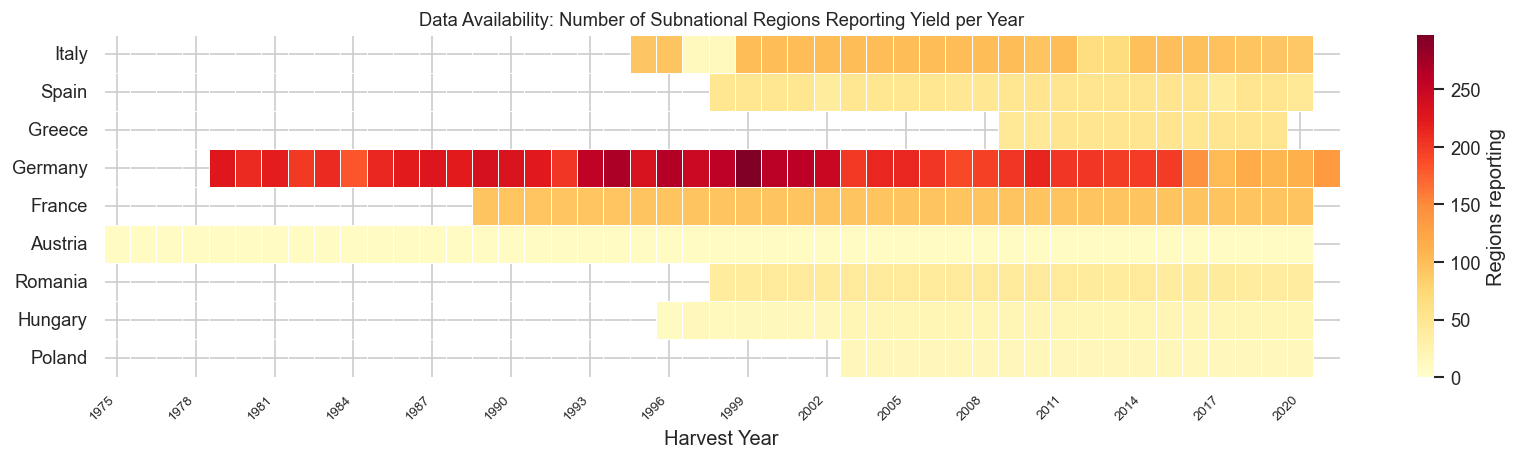

Saved: fig_coverage_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 4))

pivot = (
    master.groupby(['country', 'harvest_year'])['yield']
    .count()
    .unstack('harvest_year')
    .reindex(COUNTRIES)
)
pivot.index = [COUNTRY_NAMES[c] for c in pivot.index]

sns.heatmap(
    pivot, ax=ax, cmap='YlOrRd',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Regions reporting'},
    vmin=0
)
ax.set_title('Data Availability: Number of Subnational Regions Reporting Yield per Year',
             fontsize=11)
ax.set_xlabel('Harvest Year')
ax.set_ylabel('')


xticks = ax.get_xticks()
xlabels = [l.get_text() for l in ax.get_xticklabels()]
step = max(1, len(xlabels) // 15)
ax.set_xticks(xticks[::step])
ax.set_xticklabels(xlabels[::step], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('./fig_coverage_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_coverage_heatmap.png')

---
## 5. Descriptive Statistics
### 5.1 Overall Feature Summary

In [12]:
desc = master[FEATURE_COLS].describe().T
desc.index.name = 'Feature'
desc = desc.round(3)
desc.rename(columns={'count': 'N', 'mean': 'Mean', 'std': 'Std',
                     'min': 'Min', '25%': 'Q1', '50%': 'Median',
                     '75%': 'Q3', 'max': 'Max'}, inplace=True)


desc['Skewness'] = master[FEATURE_COLS].skew().round(3)
desc['Kurtosis'] = master[FEATURE_COLS].kurt().round(3)
desc['% Missing'] = (master[FEATURE_COLS].isna().mean() * 100).round(1)

pd.set_option('display.float_format', '{:.3f}'.format)
print('OVERALL DESCRIPTIVE STATISTICS')
print(desc.to_string())

OVERALL DESCRIPTIVE STATISTICS
                         N    Mean     Std     Min      Q1  Median      Q3      Max  Skewness  Kurtosis  % Missing
Feature                                                                                                           
yield            18149.000   7.638   2.427   0.000   6.200   7.800   9.230   24.086    -0.307     0.909      0.000
detrended_yield  18149.000   0.000   1.165  -9.581  -0.563   0.060   0.658   10.542    -0.619     6.152      0.000
heat_stress_days 10746.000  16.263  19.138   0.000   3.000   8.000  23.000   90.000     1.528     1.578     40.800
cwb_deficit_gs   10746.000 494.296 163.354 128.071 368.938 451.944 585.990 1103.395     0.936     0.307     40.800
tavg_jja         10746.000  20.287   2.784  12.617  17.992  19.564  22.544   29.011     0.505    -0.681     40.800
prec_gs          10746.000 430.316 174.656   9.250 319.913 420.365 517.948 1486.701     0.887     2.327     40.800
rsm_anomaly       9598.000   0.164   0.865  -3.44

### 5.2 Descriptive Statistics by Panel

In [13]:
PANELS = ['Mediterranean', 'Temperate', 'Continental']
print_cols = ['yield', 'detrended_yield', 'heat_stress_days', 'cwb_deficit_gs', 'tavg_jja', 'prec_gs']

for panel in PANELS:
    sub = master[master['panel'] == panel]
    print(f'\n{panel.upper()} PANEL (N={len(sub):,} obs, {sub["adm_id"].nunique()} regions)')
    d = sub[print_cols].describe().T.round(2)
    d['skew'] = sub[print_cols].skew().round(2)
    d['miss%'] = (sub[print_cols].isna().mean() * 100).round(1)
    print(d.to_string())


MEDITERRANEAN PANEL (N=4,028 obs, 207 regions)
                    count    mean     std     min     25%     50%     75%      max   skew  miss%
yield            4028.000   7.850   3.270   0.000   5.670   8.220  10.130   24.090 -0.170  0.000
detrended_yield  4028.000   0.000   1.370  -9.580  -0.520   0.020   0.600   10.540 -0.700  0.000
heat_stress_days 3312.000  33.280  23.270   0.000  13.000  32.000  50.000   90.000  0.270 17.800
cwb_deficit_gs   3312.000 643.440 171.770 128.070 527.790 639.700 767.680 1103.400 -0.120 17.800
tavg_jja         3312.000  22.990   2.570  12.770  21.870  23.410  24.710   29.010 -1.030 17.800
prec_gs          3312.000 367.740 219.770   9.250 206.390 323.190 476.430 1486.700  1.230 17.800

TEMPERATE PANEL (N=12,415 obs, 431 regions)
                     count    mean     std     min     25%     50%     75%      max   skew  miss%
yield            12415.000   7.960   1.850   0.000   6.770   8.000   9.200   14.800 -0.450  0.000
detrended_yield  12415.000  -0.0

### 5.3 Descriptive Statistics by Country

In [14]:
summary_by_country = []
for cn in COUNTRIES:
    sub = master[master['country'] == cn]
    row = {
        'Country':           COUNTRY_NAMES[cn],
        'Panel':             PANEL_MAP[cn],
        'Regions':           sub['adm_id'].nunique(),
        'Obs':               len(sub),
        'Yield mean':        round(sub['yield'].mean(), 2),
        'Yield std':         round(sub['yield'].std(), 2),
        'Yield CV (%)':      round(sub['yield'].std() / sub['yield'].mean() * 100, 1),
        'HSD mean (days)':   round(sub['heat_stress_days'].mean(), 1),
        'HSD max (days)':    round(sub['heat_stress_days'].max(), 0),
        'CWB def mean (mm)': round(sub['cwb_deficit_gs'].mean(), 1),
        'Tavg JJA (°C)':     round(sub['tavg_jja'].mean(), 1),
        'Prec GS (mm)':      round(sub['prec_gs'].mean(), 1),
    }
    summary_by_country.append(row)

sum_df = pd.DataFrame(summary_by_country)
print('SUMMARY BY COUNTRY')
print(sum_df.to_string(index=False))

SUMMARY BY COUNTRY
Country         Panel  Regions  Obs  Yield mean  Yield std  Yield CV (%)  HSD mean (days)  HSD max (days)  CWB def mean (mm)  Tavg JJA (°C)  Prec GS (mm)
  Italy Mediterranean      102 2323       7.610      2.560        33.700           29.700          85.000            572.200         23.000       460.300
  Spain Mediterranean       53 1146       8.190      3.730        45.500           38.300          90.000            746.500         22.300       243.100
 Greece Mediterranean       52  559       8.130      4.540        55.800           37.500          86.000            720.700         24.400       248.600
Germany     Temperate      327 8975       7.870      1.770        22.500            4.900          25.000            374.800         18.200       483.200
 France     Temperate       95 3026       8.150      2.090        25.600           10.300          78.000            481.600         19.400       413.000
Austria     Temperate        9  414       8.480      1.70

### 5.4 CV of Detrended Yield by Panel (RQ1 Preview)

In [15]:
print('CV OF DETRENDED YIELD BY PANEL (RQ1 preview)')
print(cv_df.groupby('panel')['cv'].describe().round(3))

print('\nCV BY COUNTRY (median)')
cv_country = cv_df.groupby(['country', 'panel'])['cv'].median().reset_index()
cv_country.columns = ['Country', 'Panel', 'Median CV (%)']
cv_country['Country'] = cv_country['Country'].map(COUNTRY_NAMES)
cv_country = cv_country.sort_values('Median CV (%)', ascending=False)
print(cv_country.to_string(index=False))

CV OF DETRENDED YIELD BY PANEL (RQ1 preview)
                count   mean    std   min    25%    50%    75%     max
panel                                                                 
Continental    79.000 24.980 11.390 8.226 18.947 23.004 30.188  81.016
Mediterranean 201.000 16.798 13.394 1.197  8.211 14.613 19.767 100.901
Temperate     430.000 13.178  8.246 2.735  9.498 11.577 14.410  89.311

CV BY COUNTRY (median)
Country         Panel  Median CV (%)
Romania   Continental         29.138
Hungary   Continental         21.869
  Spain Mediterranean         17.188
  Italy Mediterranean         15.348
 France     Temperate         12.976
Austria     Temperate         12.271
 Poland   Continental         12.214
Germany     Temperate         11.263
 Greece Mediterranean          7.218


---
## 6. Feature Distributions — Visualisation
### 6.1 Yield Distribution by Panel

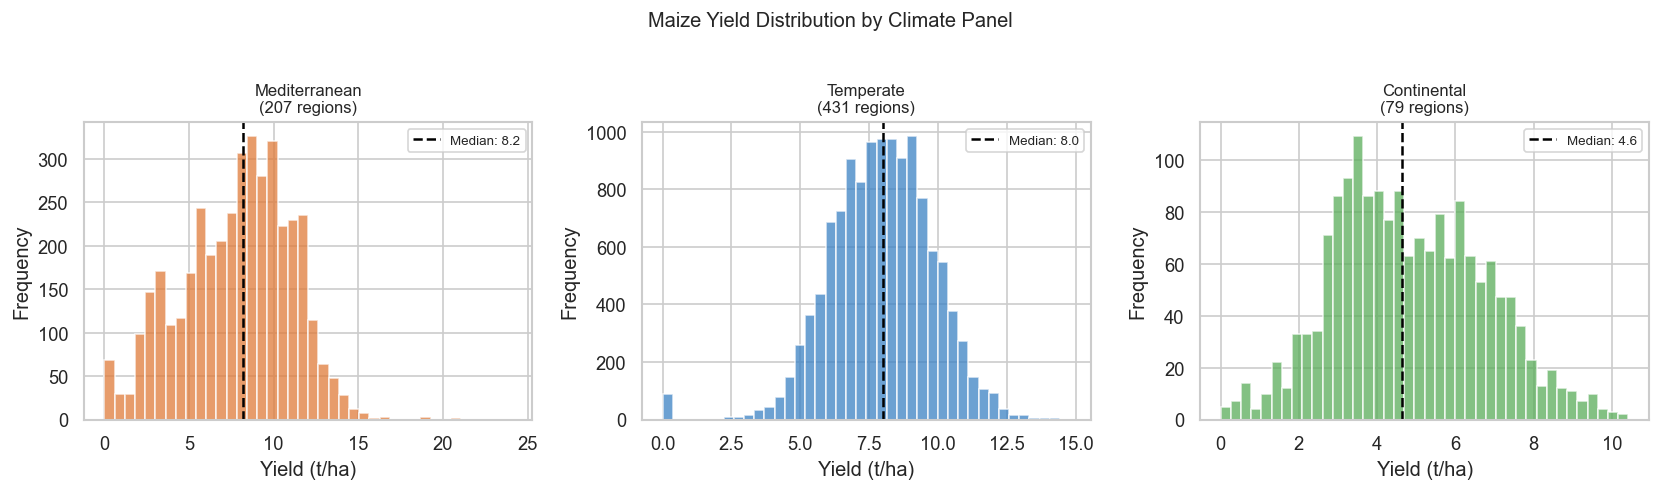

Saved: fig_yield_dist_by_panel.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, panel in zip(axes, PANELS):
    sub = master[master['panel'] == panel]
    color = PANEL_COLORS[panel]
    ax.hist(sub['yield'].dropna(), bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(sub['yield'].median(), color='black', linestyle='--', linewidth=1.5,
               label=f"Median: {sub['yield'].median():.1f}")
    ax.set_title(f'{panel}\n({sub["adm_id"].nunique()} regions)', fontsize=10)
    ax.set_xlabel('Yield (t/ha)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle('Maize Yield Distribution by Climate Panel', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('./fig_yield_dist_by_panel.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_yield_dist_by_panel.png')

### 6.2 Climate Stress Features — Distribution by Panel

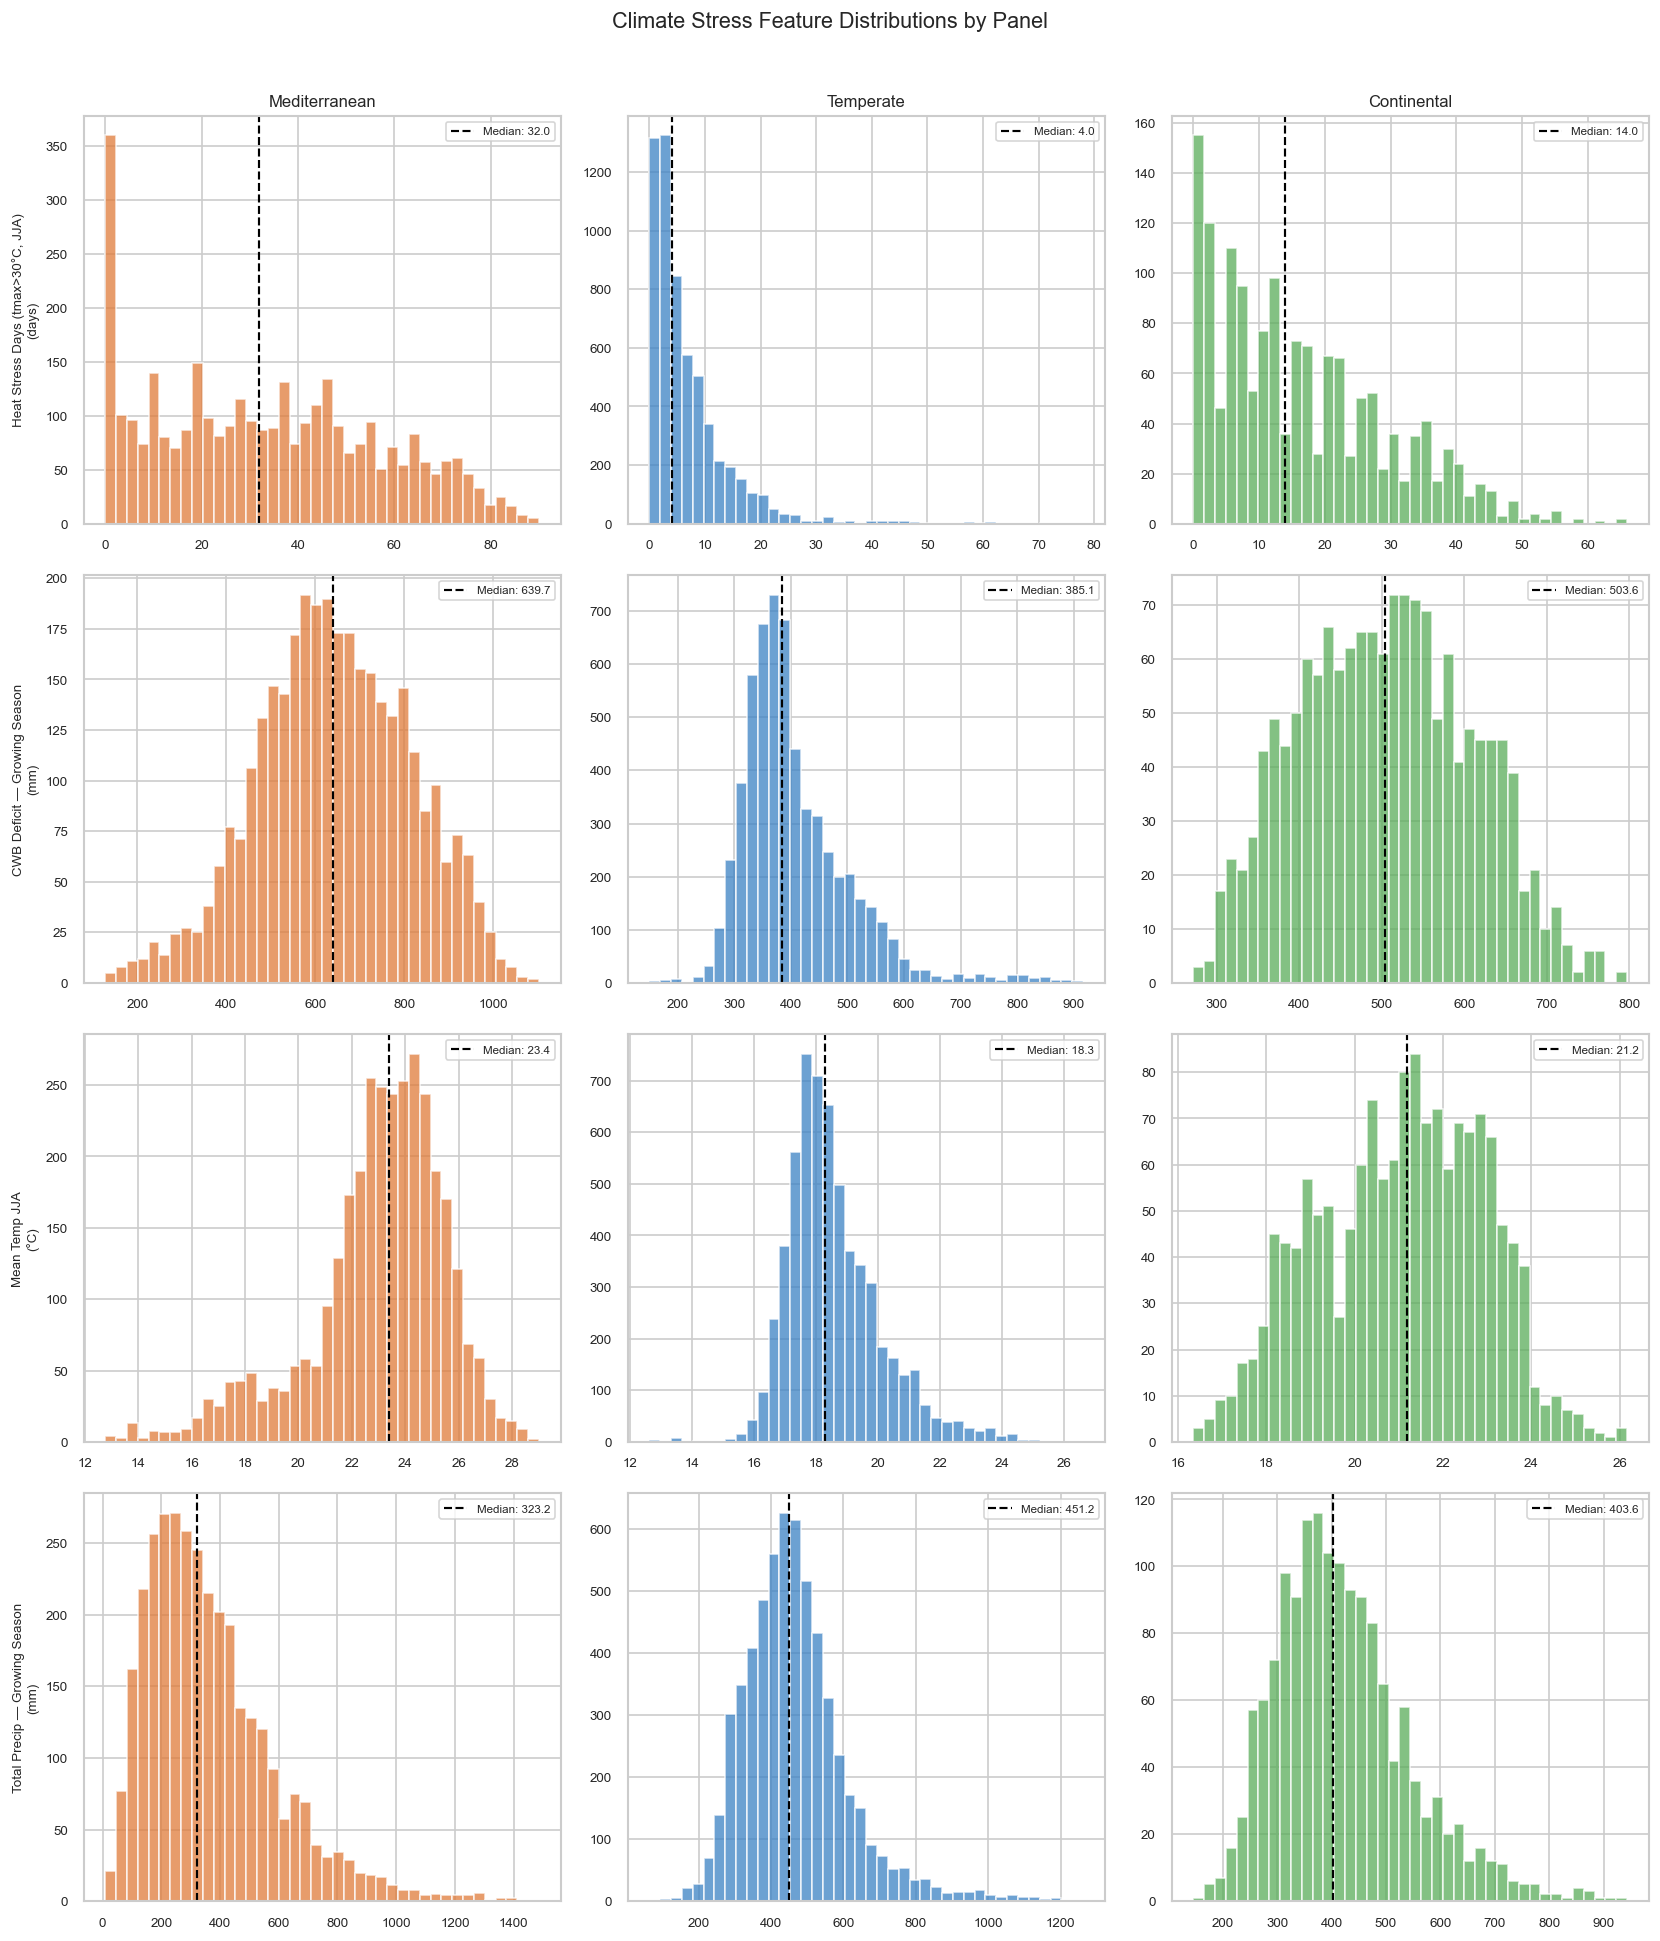

Saved: fig_features_by_panel.png


In [17]:
STRESS_FEATURES = [
    ('heat_stress_days', 'Heat Stress Days (tmax>30°C, JJA)', 'days'),
    ('cwb_deficit_gs',   'CWB Deficit — Growing Season',       'mm'),
    ('tavg_jja',         'Mean Temp JJA',                      '°C'),
    ('prec_gs',          'Total Precip — Growing Season',      'mm'),
]

fig, axes = plt.subplots(len(STRESS_FEATURES), 3, figsize=(14, 4 * len(STRESS_FEATURES)))

for row_i, (col, label, unit) in enumerate(STRESS_FEATURES):
    for col_i, panel in enumerate(PANELS):
        ax = axes[row_i][col_i]
        sub = master[(master['panel'] == panel) & master[col].notna()][col]
        color = PANEL_COLORS[panel]
        ax.hist(sub, bins=40, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(sub.median(), color='black', linestyle='--', linewidth=1.3,
                   label=f'Median: {sub.median():.1f}')
        if row_i == 0:
            ax.set_title(panel, fontsize=10)
        if col_i == 0:
            ax.set_ylabel(f'{label}\n({unit})', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=8)

fig.suptitle('Climate Stress Feature Distributions by Panel', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./fig_features_by_panel.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_features_by_panel.png')

### 6.3 CV of Detrended Yield by Panel — Boxplot (RQ1)

/var/folders/g8/1hlvtqbj25qb2y3hhh_f3dvh0000gn/T/ipykernel_17731/2533517441.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


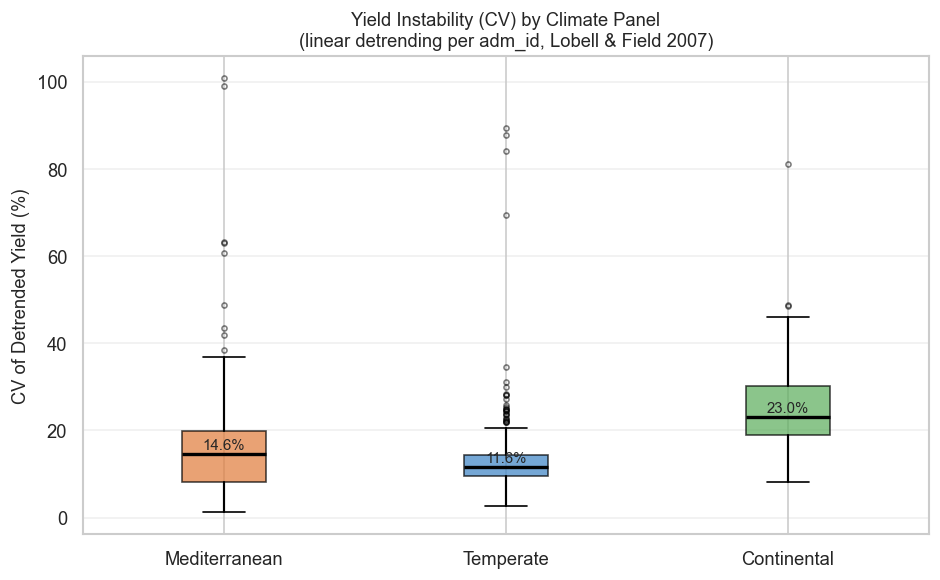

Saved: fig_cv_by_panel.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

panel_order = ['Mediterranean', 'Temperate', 'Continental']
colors      = [PANEL_COLORS[p] for p in panel_order]

bp = ax.boxplot(
    [cv_df[cv_df['panel'] == p]['cv'].dropna() for p in panel_order],
    labels=panel_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'linewidth': 1.3},
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5}
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('CV of Detrended Yield (%)', fontsize=11)
ax.set_title('Yield Instability (CV) by Climate Panel\n'
             '(linear detrending per adm_id, Lobell & Field 2007)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Annotate medians
for i, panel in enumerate(panel_order):
    med = cv_df[cv_df['panel'] == panel]['cv'].median()
    ax.text(i + 1, med + 0.5, f'{med:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./fig_cv_by_panel.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_cv_by_panel.png')

### 6.4 Correlation Matrix — All Features

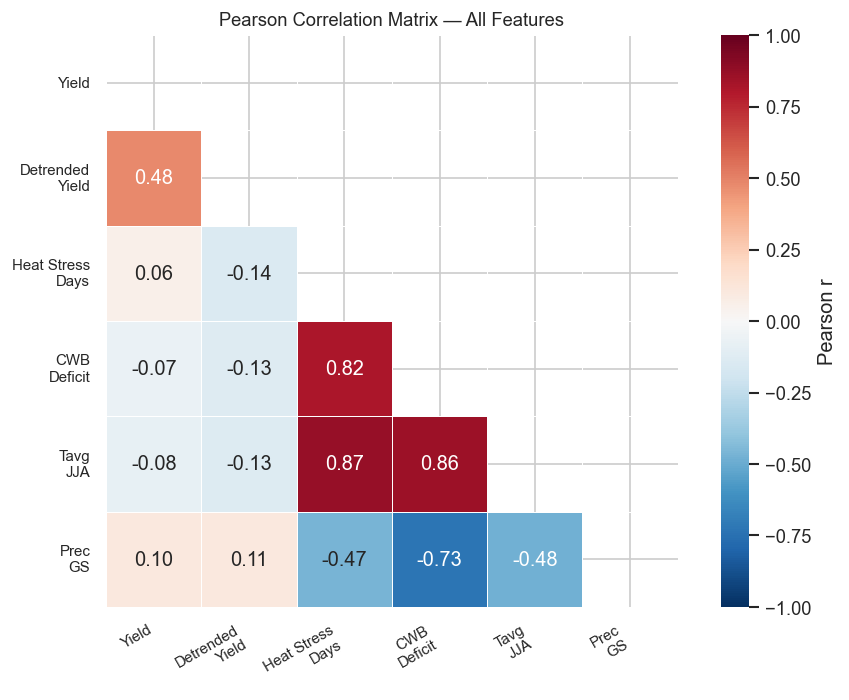

Saved: fig_correlation_matrix.png


In [19]:
corr_cols = ['yield', 'detrended_yield', 'heat_stress_days',
             'cwb_deficit_gs', 'tavg_jja', 'prec_gs']
corr = master[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'label': "Pearson r"}
)
labels = ['Yield', 'Detrended\nYield', 'Heat Stress\nDays', 'CWB\nDeficit', 'Tavg\nJJA', 'Prec\nGS']
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)
ax.set_title('Pearson Correlation Matrix — All Features', fontsize=11)

plt.tight_layout()
plt.savefig('./fig_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_correlation_matrix.png')

---
## 7. Missing Value Plan & Data Quality Summary

In [20]:
print('DATA QUALITY SUMMARY')
print()
print('1. DUPLICATES')
n_dup = master.duplicated(subset=['adm_id', 'harvest_year']).sum()
print(f'   → {n_dup} duplicate (adm_id, harvest_year) pairs found.')
print()

print('2. MISSING VALUES')
for col in FEATURE_COLS:
    n = master[col].isna().sum()
    pct = 100 * n / len(master)
    reason = ''
    if col == 'rsm_anomaly' and pct > 0:
        reason = '<- structural (soil moisture data starts 2003)'
    print(f'   {col:<25}: {n:>5} missing ({pct:>5.1f}%)  {reason}')
print()

print('3. OUTLIER HANDLING')
print('Method: IQR × 3.0 (extreme outlier threshold)')
print('-> Outliers in raw yield below 0.5 t/ha will be removed (likely reporting errors)')
print('-> Natural extreme years (2003 drought, 2018 heat wave) are RETAINED')
print('->Outliers in climate features retained (they represent real events)')
print()

print('4. MISSING VALUE STRATEGY')
print('rsm_anomaly: Not imputed. Used only in supplementary model (2003–2021).')
print('heat_stress_days / cwb_deficit_gs / tavg_jja / prec_gs:')
print('-> Any remaining NaN from meteo file gaps will be imputed using the')
print('region (adm_id) historical mean for that feature (mean imputation).')
print('-> The number of imputed values is small (< 1%) for all 4 countries.')
print()

print('5. NOTE ON GREECE (EL)')
print('-> Only 11 years of data (2009–2019). CV estimates for EL are based on ')
print('fewer observations and are less stable than for other countries.')     
print('This limitation will be stated in the Results section.')

DATA QUALITY SUMMARY

1. DUPLICATES
   → 0 duplicate (adm_id, harvest_year) pairs found.

2. MISSING VALUES
   yield                    :     0 missing (  0.0%)  
   detrended_yield          :     0 missing (  0.0%)  
   heat_stress_days         :  7403 missing ( 40.8%)  
   cwb_deficit_gs           :  7403 missing ( 40.8%)  
   tavg_jja                 :  7403 missing ( 40.8%)  
   prec_gs                  :  7403 missing ( 40.8%)  
   rsm_anomaly              :  8551 missing ( 47.1%)  <- structural (soil moisture data starts 2003)

3. OUTLIER HANDLING
Method: IQR × 3.0 (extreme outlier threshold)
-> Outliers in raw yield below 0.5 t/ha will be removed (likely reporting errors)
-> Natural extreme years (2003 drought, 2018 heat wave) are RETAINED
->Outliers in climate features retained (they represent real events)

4. MISSING VALUE STRATEGY
rsm_anomaly: Not imputed. Used only in supplementary model (2003–2021).
heat_stress_days / cwb_deficit_gs / tavg_jja / prec_gs:
-> Any remaining Na

In [21]:
master_clean = master.copy()

n_before = len(master_clean)
master_clean = master_clean[master_clean['yield'] >= 0.5]
n_removed = n_before - len(master_clean)
print(f'Rows removed (yield < 0.5 t/ha): {n_removed}')
print(f'Final master dataset shape: {master_clean.shape}')

master_clean.to_csv('./master_dataset.csv', index=False)
cv_df.to_csv('./cv_per_adm.csv', index=False)
print('Saved: master_dataset.csv, cv_per_adm.csv')

master_ml = master_clean[master_clean['harvest_year'] >= 2001].copy()
master_ml = master_ml.dropna(subset=['heat_stress_days', 'cwb_deficit_gs', 'tavg_jja', 'prec_gs'])
print(f'ML dataset (2001+, complete climate features): {master_ml.shape}')
print(f'Years: {master_ml["harvest_year"].min()}–{master_ml["harvest_year"].max()}')
print(f'Regions: {master_ml["adm_id"].nunique()}')
master_ml.to_csv('./master_ml_dataset.csv', index=False)
print('Saved: master_ml_dataset.csv')


Rows removed (yield < 0.5 t/ha): 167
Final master dataset shape: (17982, 12)
Saved: master_dataset.csv, cv_per_adm.csv
ML dataset (2001+, complete climate features): (10662, 12)
Years: 2001–2021
Regions: 671
Saved: master_ml_dataset.csv


---
## 8. Final Feature Summary Table

| Feature | Type | Window | Unit | Role | Source |
|---|---|---|---|---|---|
| `yield` | Raw | Annual | t/ha | Target (RQ2) / base for RQ1 | CY-Bench yield file |
| `detrended_yield` | Engineered | Annual | t/ha | Target (RQ2), basis for CV | OLS residual per adm_id |
| `cv` | Engineered | All years per adm_id | % | RQ1 test variable | SD/mean of detrended yield |
| `panel` | Categorical | — | — | RQ1 grouping variable | Country-to-panel mapping |
| `heat_stress_days` | Engineered | June–Aug | days | RQ2 predictor | tmax > 30°C count, meteo file |
| `cwb_deficit_gs` | Engineered | Apr–Sep | mm | RQ2 predictor | Sum of negative CWB, meteo file |
| `tavg_jja` | Aggregated | June–Aug | °C | RQ2 predictor | Mean tavg, meteo file |
| `prec_gs` | Aggregated | Apr–Sep | mm | RQ2 predictor | Sum prec, meteo file |
| `rsm_anomaly` | Engineered | July–Aug | σ | Supplementary (2003+) | Root-zone soil moisture file |

**Total primary features for RQ2 ML model:** 4 (heat_stress_days, cwb_deficit_gs, tavg_jja, prec_gs)  
**Supplementary feature:** 1 (rsm_anomaly, 2003–2021 only)